## 随机 filter 

In [9]:
import numpy as np
import torch
import torch.nn as nn


class myConvModel(nn.Module):
    def __init__(self, out_channels=3):
        super().__init__()
        self.conv = nn.Conv2d(3, out_channels, kernel_size=3, stride=1, padding=1, bias=False)

    def forward(self, x):
        return self.conv(x)

    def __call__(self, x):
        # Support the tutorial-style numpy NHWC input and return NHWC numpy output.
        if isinstance(x, np.ndarray):
            xt = torch.from_numpy(x).permute(0, 3, 1, 2).float()
            with torch.no_grad():
                yt = super().__call__(xt)
            return yt.permute(0, 2, 3, 1).cpu().numpy()
        return super().__call__(x)


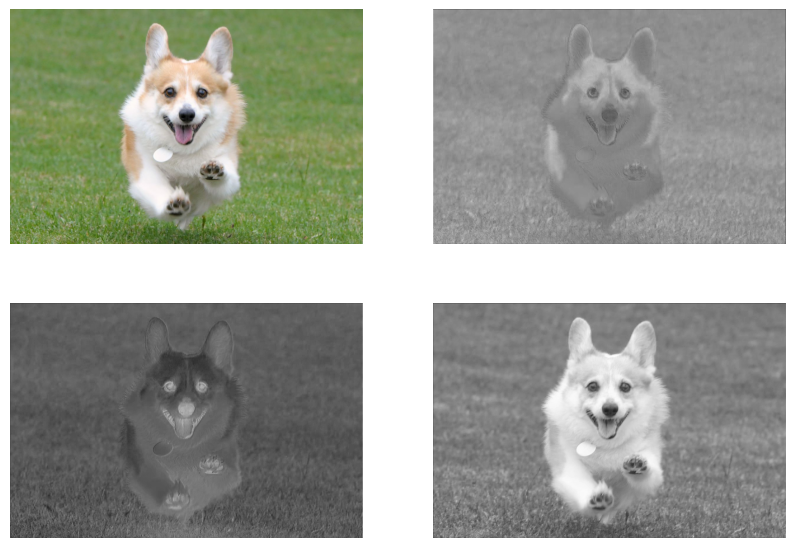

In [10]:
random_conv = myConvModel()
import numpy
import pylab
from PIL import Image
import numpy as np

# open random image of dimensions 639x516
img = Image.open(open('corgi.jpg', 'rb'))
img = numpy.asarray(img, dtype='float64') / 256.
img = np.expand_dims(img, axis=0)
img_out = random_conv(img)

pylab.figure(figsize=(10,7))
pylab.subplot(2, 2, 1); pylab.axis('off'); pylab.imshow(img[0, :, :, :])
pylab.subplot(2, 2, 2); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 0], cmap='gray')
pylab.subplot(2, 2, 3); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 1], cmap='gray')
pylab.subplot(2, 2, 4); pylab.axis('off'); pylab.imshow(img_out[0, :, :, 2], cmap='gray')
pylab.show()
